## Installation and includes
##### Install cuda
##### Install cudnn
##### Install monai
##### Install pytorch

In [1]:
# Cellule 1 — toujours en premier
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Cellule 2 — imports
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os 
from glob import glob
import torch

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    Resized,
    ToTensord,
    Spacingd,
    CropForegroundd,
    Orientationd,
    RandFlipd,
    RandRotate90d,
    RandGaussianNoised,
)
from monai.data import Dataset, DataLoader
from monai.utils import first
from monai.utils import set_determinism
import matplotlib.pyplot as plt

In [3]:
#load images
#do any transforms
#need to convert patient into torch_tensor

def prepare(in_dir, pixdim=(1.5,1.5,1.0), a_min=-200, a_max=200, spatial_size =[128,128,80],cache=False):
    
    """
    This function is for preprocessing, it contains the basic transformations with a CPU thanks MONAI documentation
    """
    
    set_determinism(seed=0)
    
    path_train_images = sorted(glob(os.path.join(in_dir,'Train','images','*.nii')))
    path_train_labels = sorted(glob(os.path.join(in_dir,'Train','labels','*.nii')))

    path_test_images = sorted(glob(os.path.join(in_dir,'Test','images','*.nii')))
    path_test_labels = sorted(glob(os.path.join(in_dir,'Test','labels','*.nii')))
    
    train_files = [{"image": image_name, "label": label_name} for image_name, label_name in zip(path_train_images, path_train_labels)]
    test_files = [{"image": image_name, "label": label_name} for image_name, label_name in zip(path_test_images, path_test_labels)]

    train_transforms = Compose(
        [
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys=['image', 'label']), #AddChannelId does not exist anymore => replaced by EnsureChannelFirstd
            Spacingd(keys =['image','label'], pixdim = pixdim, mode =("bilinear","nearest")),
            Orientationd(keys=['image','label'], axcodes="RAS"),
            ScaleIntensityRanged(keys=['image'], a_min=a_min, a_max=a_max, b_min=0.0,  b_max=1.0,clip=True),
            CropForegroundd(keys=['image','label'], source_key='image'),
            Resized(keys=['image','label'],spatial_size=spatial_size),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),  # flip gauche/droite
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),  # flip avant/arrière
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),  # flip haut/bas
            RandRotate90d(keys=['image', 'label'], prob=0.5, max_k=3),     # rotation 90°/180°/270°
            RandGaussianNoised(keys=['image'], prob=0.3, mean=0.0, std=0.1), # bruit gaussien sur l'image uniquement
            ToTensord(keys=['image', 'label']),
        ]
    )
    
    test_transforms = Compose(
        [
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys=['image', 'label']), #AddChannelId does not exist anymore => replaced by EnsureChannelFirstd
            Spacingd(keys =['image','label'], pixdim = pixdim, mode =("bilinear","nearest")),
            Orientationd(keys=['image','label'], axcodes="RAS"),
            ScaleIntensityRanged(keys=['image'], a_min=a_min, a_max=a_max, b_min=0.0,  b_max=1.0,clip=True),
            CropForegroundd(keys=['image','label'], source_key='image'),
            Resized(keys=['image','label'],spatial_size=spatial_size),
            ToTensord(keys=['image', 'label']),
        ]
    )


    if cache : 
        train_ds=CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0)
        train_loader =DataLoader(train_ds,batch_size=1,shuffle=True, num_workers=0, pin_memory=False)
        
        test_ds=CacheDataset(data=test_files, transform=test_transforms, cache_rate=1.0)
        test_loader =DataLoader(test_ds,batch_size=1,shuffle=False, num_workers=0, pin_memory=False)
        
        return train_loader, test_loader
    
    else :
        train_ds=Dataset(data=train_files, transform=train_transforms)
        train_loader =DataLoader(train_ds,batch_size=1,shuffle=True, num_workers=0, pin_memory=False)
        
        test_ds=Dataset(data=test_files, transform=test_transforms)
        test_loader =DataLoader(test_ds,batch_size=1, num_workers=0, pin_memory=False)
        
        return train_loader, test_loader
        

In [4]:
def show_patient(data, SLICE_NUMBER=1,train=True, test=False) :
    
    """
    This function is used to show one patient randomly in your datasets, so you can see if there is a problem or something to change
    "data" : patients from the data loader, call the function prepare first and apply the transforms and then visualize the patient
    "SLICE_NUMBER" : the slice number you want to show from the patient
    "train" : show a patient from the training data
    "test" : show a patient from testing data
    """
    
    check_patient_train, check_patient_test = data
    
    view_train_patient=first(check_patient_train)
    view_test_patient=first(check_patient_test)
    
    if train :
        plt.figure("Visualisation Train", (12, 6))
        plt.subplot(1,2,1)
        plt.title(f"img {SLICE_NUMBER}")
        plt.imshow(view_train_patient["image"][0,0,:,:,SLICE_NUMBER], cmap="gray")
        
        plt.subplot(1,2,2)
        plt.title(f"label {SLICE_NUMBER}")
        plt.imshow(view_train_patient["label"][0,0,:,:,SLICE_NUMBER])
        plt.show()
        
    if test : 
        plt.figure("Visualisation Test", (12, 6))
        plt.subplot(1,2,1)
        plt.title(f"img {SLICE_NUMBER}")
        plt.imshow(view_test_patient["image"][0,0,:,:,SLICE_NUMBER], cmap="gray")
        
        plt.subplot(1,2,2)
        plt.title(f"label {SLICE_NUMBER}")
        plt.imshow(view_test_patient["label"][0,0,:,:,SLICE_NUMBER])
        plt.show()

C:\Users\rowan\anaconda\envs\dicom_env\lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


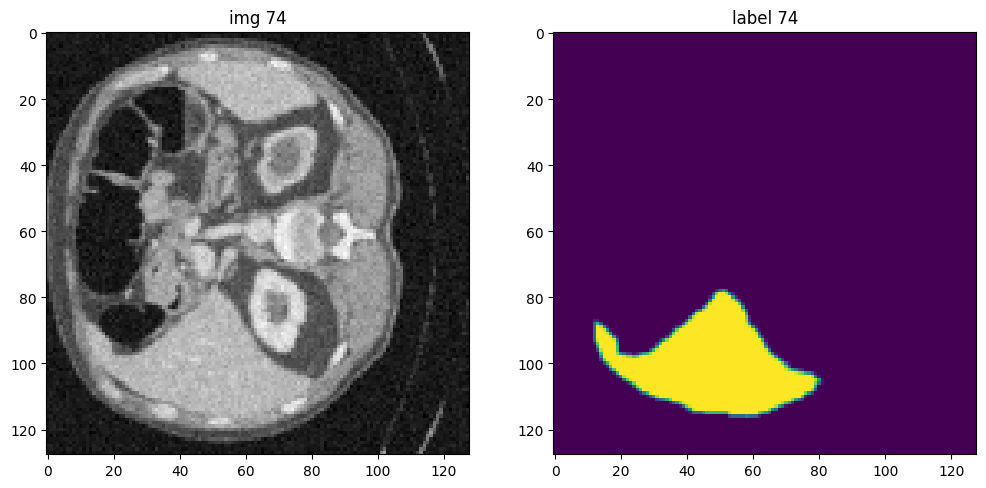

In [5]:
in_dir = 'C:/Users/rowan/Desktop/Projets/Liver Segmentation/datasets/nifti_files'
patient = prepare(in_dir)
show_patient(patient, 74)